# RAPID-MFA-6b: Varying lifetime over time

## Descriptions
This variant of the stock driven model utilizes a _changing survival curve_, meaning that products get continously used longer, making the shape of the survival curve change every year, therefore making each cohort have a specific surivival curve.

Use this model to:

- Analyze the effect on lifetime after the product is already in use, (i.e., products being used for longer lifespans as time passes than originally considered as shown in this example, products being used less than expected as new technology arises, etc).
- Apply the "cohort effect" (with varying survival curves per year) of lifetimes as defined in _Krych, K., Müller, D. B., & Pettersen, J. B. (2025). The “nature” and “nurture” of product lifetimes in dynamic stock modeling. Journal of Industrial Ecology, 29(1), 6-18._

This model takes the following inputs:
- A _stock_ time series of the product.
- The _parameters_ for the _baseline_ survival curve (shape and scale).
- The _shape_ for final year of the _varying lifetime_ survival curve.

It produces two main outputs:
- The MFA model using only the _baseline_ survival curve.
- The MFA model using the _varying lifetime_ survival curve.

### Notes
The only true modification in this model is the creation of the survival curves matrix. Therefore:
1. This example uses the stock-driven model, but it can be replaced with the flow driven model. 
1. This example uses Weibull survival curves, but they can be replaced with any other curves.

### Exogenous variables
__Stocks:__ mock values for years 1998 to 2050, for number of vehicles.

__Survival curve:__ generated from using mock values for shape and scale.


### Relations with other RAPID-MFA codes
- `RAPID-MFA-2: The stock driven model`: The example in this codes uses the modelling steps are following those in this notebook. 
- `RAPID-MFA-6a: One-off varying lifetime`: this alternative model shows the variation of lifetime spans changing after one specific point in time. 

## Version, licence and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [22]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns

## 2. Define example input data

In [23]:
# %% 2. Define example input data
input_data = pd.Series([0, 17, 9367, 29639, 65611, 112994, 196655, 405237, 655629, 1002834, 
                        1307203, 1584131, 1836332, 2092277, 2537144, 3074043, 3567853, 4207156, 
                        4945879, 5797925, 6778277, 7902746, 9187646, 10649295, 12303394, 14164318, 
                        16244276, 18552466, 21094228, 23870337, 26876417, 30102657, 33533764, 
                        37149274, 40924083, 44829315, 48833234, 52902345, 57002464, 61099726, 
                        65161509, 69157195, 73058775, 76841335, 80483330, 83966772, 87277263, 
                        90403948, 93339367, 96079253, 98622261, 100969690, 103125124], 
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 
                                2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 
                                2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 
                                2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 
                                2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 
                                2048, 2049, 2050])  

# Parameters for the survival curve
ages = range(0, len(input_data))  
shape = 2.428914875
scale = 16.93851375
scale_varying_life = 25.58326  

In [24]:
survival_curve_baseline = scipy.stats.weibull_min.sf(ages, shape, 0, scale)

## 3. Run the stock-driven model

The steps from hereon are a repetition of notebook 2, but with different input data. If you want a more detailed account on how to do this, see notebook 2.

<Axes: ylabel='vehicles/year'>

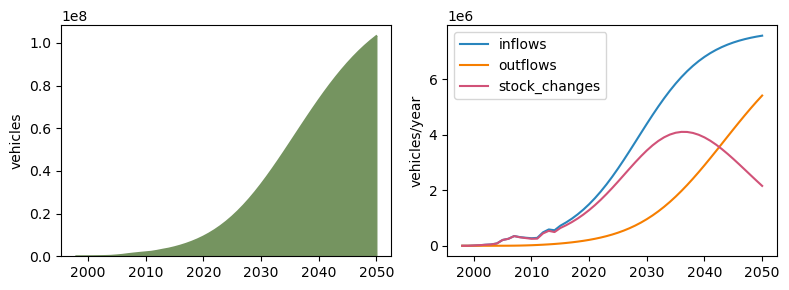

In [25]:
# %% 3. Run the stock-driven model
# %%% 3.1 Set up the MFA system
units = {'time_interval': 'year', 
         'flows': 'vehicles/year', 
         'stocks': 'vehicles'
         }

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system_baseline_vehicles = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                                         'inflows', 
                                                                         'outflows', 
                                                                         'stock_changes'])

mfa_system_baseline_vehicles['stocks'] = input_data

# %%% 3.2 Create survival curves matrix
# create survival curves matrix filled with zeros
survival_curve_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curve_matrix_baseline.loc[cohort: , cohort] = survival_curve_baseline[0 : cohort_stop - cohort]
   
# %%% 3.3 Create cohorts survival matrix
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_baseline_vehicles.loc[cohort, 'inflows'] = (
        mfa_system_baseline_vehicles.loc[cohort, 'stocks'] - cohorts_survival_matrix_baseline.loc[cohort, : cohort - 1].sum()
    ) / survival_curve_matrix_baseline.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix_baseline.loc[:, cohort] = survival_curve_matrix_baseline.loc[:, cohort] * mfa_system_baseline_vehicles.loc[cohort, 'inflows']
    
# %%% 3.4 Calculate the MFA system
mfa_system_baseline_vehicles["stock_changes"] = np.diff(mfa_system_baseline_vehicles["stocks"], prepend=0)
mfa_system_baseline_vehicles["outflows"] = mfa_system_baseline_vehicles["inflows"] - mfa_system_baseline_vehicles["stock_changes"]

# visualize the results of the MFA for vehicles
mfa_system_baseline_vehicles_fig, mfa_system_baseline_vehicles_ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), tight_layout=True)
mfa_system_baseline_vehicles['stocks'].plot(ylabel=units['stocks'], 
                            kind="area", color='#759460', ax=mfa_system_baseline_vehicles_ax[0])

mfa_system_baseline_vehicles[['inflows', 'outflows', 'stock_changes']].plot(ylabel=units['flows'], 
                                                            color=["#2985BD", "#F67E00", "#D15278"],
                                                            ax=mfa_system_baseline_vehicles_ax[1])

## 4. Calculate the model with life extension

In [ ]:
# %% 4. Calculate the model with life extension
# %%% 4.1 Create the survival curves matrix

mfa_system_varying_life_vehicles = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                                         'inflows', 
                                                                         'outflows', 
                                                                         'stock_changes'])

mfa_system_varying_life_vehicles['stocks'] = input_data
mfa_system_varying_life_vehicles['survival_curve_scale'] = np.linspace(scale, scale_varying_life, len(timeframes))

# Generate temporary survival curves that call the correct scale parameter from the interpolated series 
survival_curves_matrix_varying_life = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)  # create an initial survival curves matrix filled with zeros
for cohort in cohorts:
    survival_curve_varying_life = scipy.stats.weibull_min.sf(ages, 
                                                   shape,
                                                   loc = 0, # Location is not defined in this scenario, so we leave it at 0, the default value. Location shifts the curve along the x-axis.
                                                   scale = mfa_system_varying_life_vehicles.loc[cohort, 'survival_curve_scale']
                                                   )
    survival_curves_matrix_varying_life.loc[cohort: , cohort] = survival_curve_varying_life[0 : cohort_stop - cohort]

# %%% 4.2 Calculate the new MFA system with the life extension
# From here on it is identical as the original MFA system, but using the new survival curve
mfa_system_varying_life_vehicles = pd.DataFrame(index=timeframes, columns = ['stocks', 
                                                                            'inflows', 
                                                                            'outflows', 
                                                                            'stock_changes'])

mfa_system_varying_life_vehicles['stocks'] = input_data

cohorts_survival_matrix_varying_life = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_varying_life_vehicles.loc[cohort, 'inflows'] = (
        mfa_system_varying_life_vehicles.loc[cohort, 'stocks'] - cohorts_survival_matrix_varying_life.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix_varying_life.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix_varying_life.loc[:, cohort] = survival_curves_matrix_varying_life.loc[:, cohort] * mfa_system_varying_life_vehicles.loc[cohort, 'inflows']
    
mfa_system_varying_life_vehicles["stock_changes"] = np.diff(mfa_system_varying_life_vehicles["stocks"], prepend=0)
mfa_system_varying_life_vehicles["outflows"] = mfa_system_varying_life_vehicles["inflows"] - mfa_system_varying_life_vehicles["stock_changes"]

## 5. Compare the two lifetime scenarios

Text(0.5, 1.0, 'lifetime extension scenario')

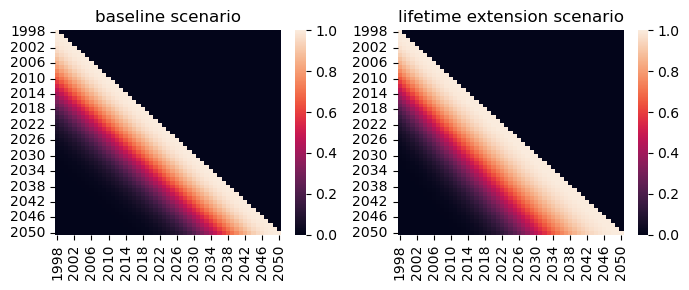

In [27]:
# %% 5. Compare the two lifetime scenarios 
# comparison of the original and new lifetime extension survival curve matrices 
compare_fig, compare_ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), tight_layout=True)
sns.heatmap(survival_curve_matrix_baseline, annot=False, ax=compare_ax[0])
compare_ax[0].set_title("baseline scenario")
sns.heatmap(survival_curves_matrix_varying_life, annot=False, ax=compare_ax[1])
compare_ax[1].set_title("lifetime extension scenario")

<Axes: title={'center': 'lifetime extension scenario'}, ylabel='vehicles'>

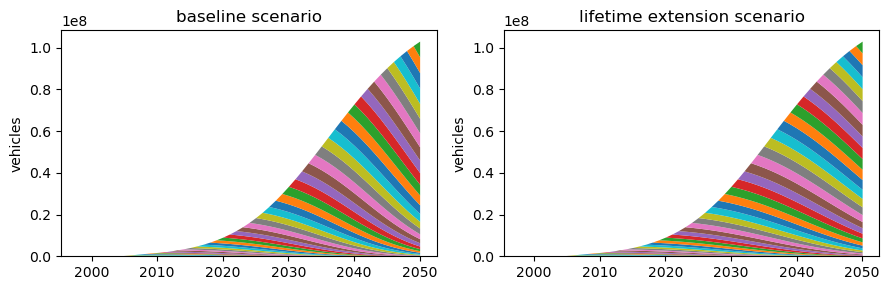

In [28]:
# a comparison of the baseline and lifetime extension stocks-by-cohorts
compare_fig, compare_ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 3), tight_layout=True)
cohorts_survival_matrix_baseline.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['stocks'], title="baseline scenario", ax=compare_ax[0])
cohorts_survival_matrix_varying_life.plot(kind="area", stacked=True, legend = False, lw=0, ylabel=units['stocks'], title="lifetime extension scenario", ax=compare_ax[1])